In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_iris

In [3]:
data=load_iris()

In [4]:
df = pd.DataFrame(data.data, columns = data.feature_names)

In [5]:
X = df
y = data.target

In [6]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1)

In [7]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dt=DecisionTreeClassifier()

In [10]:
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [2, 3, 5, 7, 10,None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"],
    "splitter":["best","random"]
}

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_grid,
    n_iter=20,        # number of random combinations to try
    cv=5,             # 5-fold cross-validation
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [11]:
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,DecisionTreeClassifier()
,param_distributions,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 3, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [12]:
random_search.best_params_

{'splitter': 'random',
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 7,
 'criterion': 'entropy'}

In [13]:
random_search.best_score_

0.9523809523809523

In [15]:
dt=DecisionTreeClassifier(splitter='random',min_samples_split= 2,min_samples_leaf= 1,criterion= 'log_loss')

In [16]:
dt.fit(x_train,y_train)

,criterion,'log_loss'
,splitter,'random'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
y_pred=dt.predict(x_test)

In [18]:
from sklearn.metrics import *

In [19]:
accuracy_score(y_test,y_pred)

1.0

In [20]:
confusion_matrix(y_test,y_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]], dtype=int64)

[Text(0.4230769230769231, 0.9444444444444444, 'x[3] <= 2.003\nlog_loss = 1.58\nsamples = 105\nvalue = [31, 37, 37]'),
 Text(0.34615384615384615, 0.8333333333333334, 'x[3] <= 0.634\nlog_loss = 1.548\nsamples = 89\nvalue = [31, 37, 21]'),
 Text(0.3846153846153846, 0.8888888888888888, 'True  '),
 Text(0.2692307692307692, 0.7222222222222222, 'log_loss = 0.0\nsamples = 31\nvalue = [31, 0, 0]'),
 Text(0.4230769230769231, 0.7222222222222222, 'x[2] <= 4.705\nlog_loss = 0.944\nsamples = 58\nvalue = [0, 37, 21]'),
 Text(0.23076923076923078, 0.6111111111111112, 'x[0] <= 5.39\nlog_loss = 0.196\nsamples = 33\nvalue = [0, 32, 1]'),
 Text(0.15384615384615385, 0.5, 'x[3] <= 1.571\nlog_loss = 0.65\nsamples = 6\nvalue = [0, 5, 1]'),
 Text(0.07692307692307693, 0.3888888888888889, 'log_loss = 0.0\nsamples = 5\nvalue = [0, 5, 0]'),
 Text(0.23076923076923078, 0.3888888888888889, 'log_loss = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.3076923076923077, 0.5, 'log_loss = 0.0\nsamples = 27\nvalue = [0, 27, 0

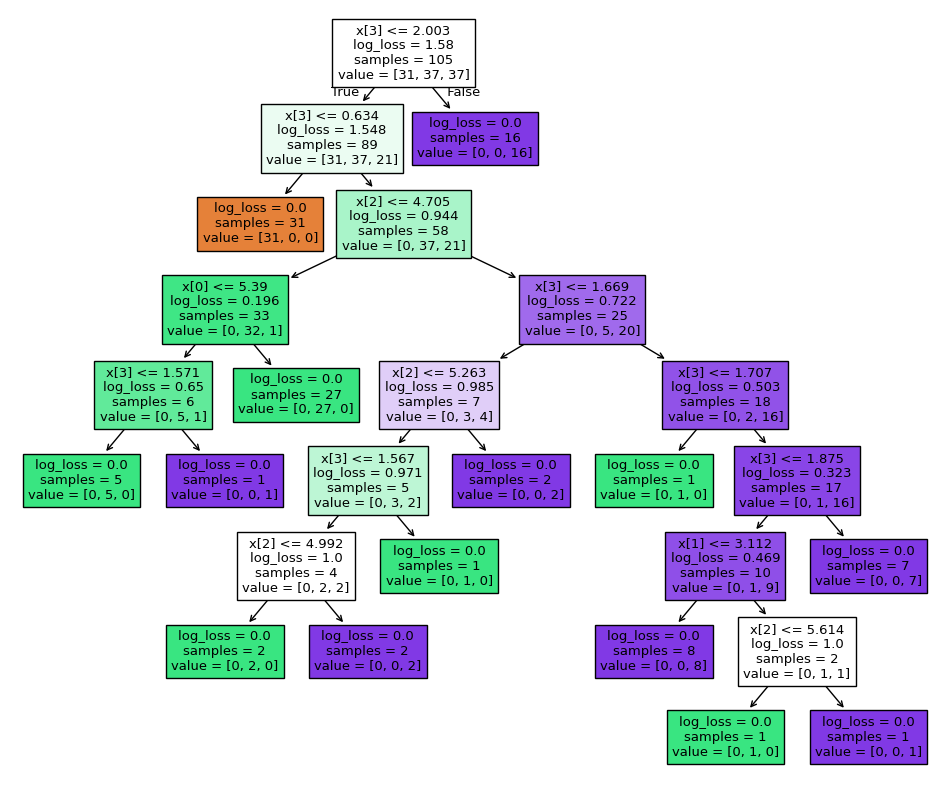

In [21]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(dt,filled=True)

In [22]:
import matplotlib.pyplot as plt

In [23]:
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()

In [24]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df['Price']=data.target

In [25]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [26]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [27]:
parameter={
 'criterion':['squared_error','friedman_mse','absolute_error','poisson'],
  'splitter':['best','random'],
  'max_depth':[1,2,3,4,5,6,None],
  'max_features':['auto', 'sqrt', 'log2',None]
    
}
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()

In [29]:
from sklearn.model_selection import GridSearchCV
model = GridSearchCV(regressor, param_grid=parameter, cv = 3, scoring = 'neg_mean_squared_error',n_jobs=-1,verbose=1)

In [30]:
model.fit(X_train,y_train)

Fitting 3 folds for each of 224 candidates, totalling 672 fits


,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'friedman_mse'


In [31]:
y_pred=model.predict(X_test)

In [32]:
r2_score(y_test,y_pred)

0.6542857202482537